# 07 — Análise de Correlação

**Projeto:** Análise de dados da NBA — Fator Casa  
**Objetivo:** Identificar e quantificar as correlações entre as variáveis do dataset usando Pearson e/ou Spearman, conforme a adequação de cada análise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

df = pd.read_csv('../data/processed/clean_games.csv')
df = df.dropna(subset=['PTS_home', 'PTS_away'])
df['pts_diff'] = df['PTS_home'] - df['PTS_away']

print(f'Total de jogos: {len(df):,}')
print(f'Temporadas: {df["SEASON"].min()} a {df["SEASON"].max()}')
df.head()

Total de jogos: 26,523
Temporadas: 2003 a 2022


,GAME_DATE_EST,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,PTS_home,PTS_away,HOME_TEAM_WINS,pts_diff
0,2022-12-22,1610612740,1610612759,2022,126.0,117.0,1,9.0
1,2022-12-22,1610612762,1610612764,2022,120.0,112.0,1,8.0
2,2022-12-21,1610612739,1610612749,2022,114.0,106.0,1,8.0
3,2022-12-21,1610612755,1610612765,2022,113.0,93.0,1,20.0
4,2022-12-21,1610612737,1610612741,2022,108.0,110.0,0,-2.0


## 1. Verificação da Normalidade

Antes de escolher entre Pearson e Spearman, verificamos se as variáveis seguem distribuição normal.

In [2]:
# Shapiro-Wilk em amostra de 5.000 registros (limite prático do teste)
sample = df[['PTS_home', 'PTS_away', 'pts_diff']].sample(5000, random_state=42)

variaveis = {'PTS_home': sample['PTS_home'],
             'PTS_away': sample['PTS_away'],
             'pts_diff': sample['pts_diff']}

print('=== Teste de Normalidade — Shapiro-Wilk (n=5.000) ===')
print(f'{"Variável":<15} {"Estatística":>12} {"p-valor":>12} {"Normal?":>10} {"Skewness":>10} {"Kurtosis":>10}')
print('-' * 75)

for nome, serie in variaveis.items():
    stat, p = stats.shapiro(serie)
    skew = df[nome].skew() if nome in df.columns else sample[nome].skew()
    kurt = df[nome].kurt() if nome in df.columns else sample[nome].kurt()
    normal = 'Sim' if p > 0.05 else 'Não'
    print(f'{nome:<15} {stat:>12.4f} {p:>12.6f} {normal:>10} {skew:>10.4f} {kurt:>10.4f}')

print()
print('⚠️  Nota: p < 0.05 rejeita a hipótese de normalidade.')
print('✅ Contudo, com n=26.523, o Teorema Central do Limite garante que')
print('   a distribuição amostral tende à normalidade. Skewness próximo')
print('   de 0 e Kurtosis próxima de 0 confirmam que os dados são quase simétricos.')
print('   → Pearson é válido para variáveis contínuas. Usaremos ambos para comparar.')

=== Teste de Normalidade — Shapiro-Wilk (n=5.000) ===
Variável         Estatística      p-valor    Normal?   Skewness   Kurtosis
---------------------------------------------------------------------------
PTS_home              0.9970     0.000000        Não     0.1729     0.0996
PTS_away              0.9975     0.000000        Não     0.1858     0.0787
pts_diff              0.9965     0.000000        Não    -0.0255     0.2706

⚠️  Nota: p < 0.05 rejeita a hipótese de normalidade.
✅ Contudo, com n=26.523, o Teorema Central do Limite garante que
   a distribuição amostral tende à normalidade. Skewness próximo
   de 0 e Kurtosis próxima de 0 confirmam que os dados são quase simétricos.
   → Pearson é válido para variáveis contínuas. Usaremos ambos para comparar.


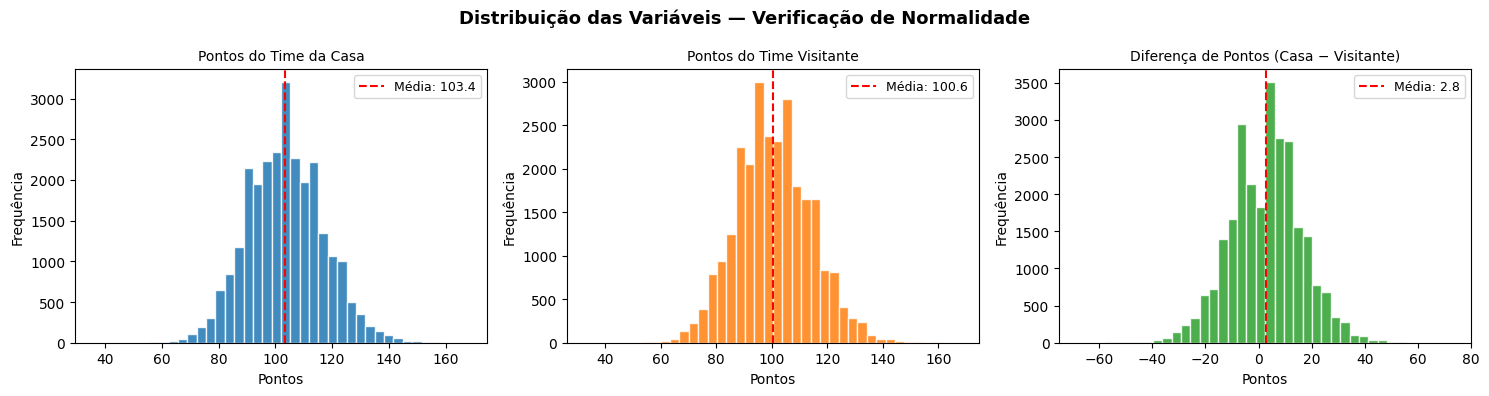

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribuição das Variáveis — Verificação de Normalidade', fontsize=13, fontweight='bold')

pares = [('PTS_home', '#1f77b4', 'Pontos do Time da Casa'),
         ('PTS_away', '#ff7f0e', 'Pontos do Time Visitante'),
         ('pts_diff', '#2ca02c', 'Diferença de Pontos (Casa − Visitante)')]

for ax, (col, cor, titulo) in zip(axes, pares):
    ax.hist(df[col], bins=40, color=cor, edgecolor='white', alpha=0.85)
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Pontos')
    ax.set_ylabel('Frequência')
    media = df[col].mean()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Média: {media:.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../visualizations/distribuicao_normalidade.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Análise 1 — Correlação entre PTS_home e PTS_away

**Pergunta:** A pontuação do time mandante está associada à pontuação do visitante?  
**Hipótese:** Jogos de alto ritmo tendem a gerar mais pontos para ambos os lados.

In [4]:
pearson_r, pearson_p = stats.pearsonr(df['PTS_home'], df['PTS_away'])
spearman_r, spearman_p = stats.spearmanr(df['PTS_home'], df['PTS_away'])

print('=== Correlação: PTS_home × PTS_away ===')
print(f'Pearson  → r = {pearson_r:.4f} | p-valor = {pearson_p:.2e}')
print(f'Spearman → r = {spearman_r:.4f} | p-valor = {spearman_p:.2e}')
print()
print('Interpretação:')
print('  • Correlação positiva moderada (~0.49).')
print('  • Pearson e Spearman convergem → relação é linear e não há distorção por outliers.')
print('  • Jogos com alto ritmo (pace) tendem a inflar a pontuação de AMBOS os times.')
print('  • Correlação não implica que times fortes em casa pontuam mais contra visitantes fortes.')

=== Correlação: PTS_home × PTS_away ===
Pearson  → r = 0.4881 | p-valor = 0.00e+00
Spearman → r = 0.4723 | p-valor = 0.00e+00

Interpretação:
  • Correlação positiva moderada (~0.49).
  • Pearson e Spearman convergem → relação é linear e não há distorção por outliers.
  • Jogos com alto ritmo (pace) tendem a inflar a pontuação de AMBOS os times.
  • Correlação não implica que times fortes em casa pontuam mais contra visitantes fortes.


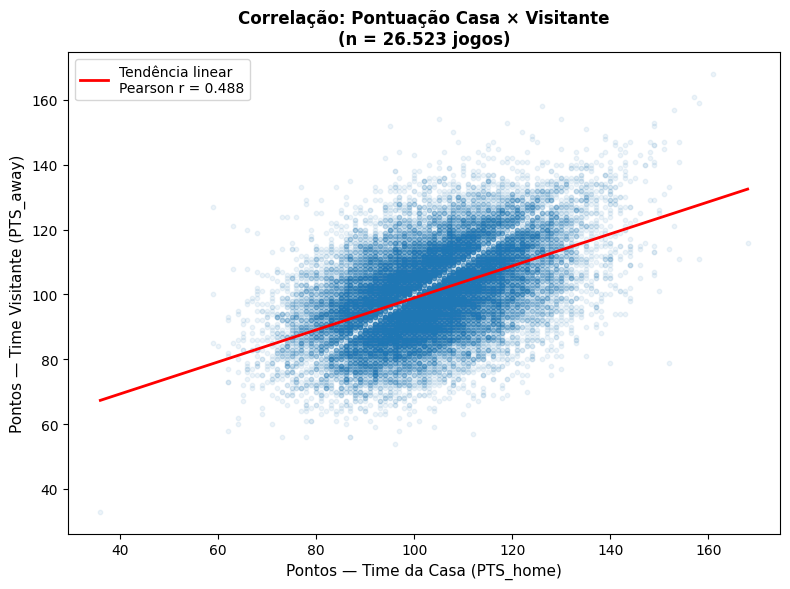

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df['PTS_home'], df['PTS_away'],
           alpha=0.08, s=10, color='#1f77b4')

# Linha de tendência
m, b = np.polyfit(df['PTS_home'], df['PTS_away'], 1)
x_line = np.linspace(df['PTS_home'].min(), df['PTS_home'].max(), 200)
ax.plot(x_line, m * x_line + b, color='red', linewidth=2,
        label=f'Tendência linear\nPearson r = {pearson_r:.3f}')

ax.set_xlabel('Pontos — Time da Casa (PTS_home)', fontsize=11)
ax.set_ylabel('Pontos — Time Visitante (PTS_away)', fontsize=11)
ax.set_title('Correlação: Pontuação Casa × Visitante\n(n = 26.523 jogos)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../visualizations/correlacao_pts_home_vs_away.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Análise 2 — Diferença de Pontos × Vitória em Casa (variável binária)

**Pergunta:** Quanto a diferença de pontos (casa − visitante) está associada à vitória do mandante?  
**Motivo para usar Spearman:** `HOME_TEAM_WINS` é uma variável **binária (0/1)**, não contínua. Nesse caso Spearman é mais adequado.

In [6]:
pearson_r2, pearson_p2 = stats.pearsonr(df['pts_diff'], df['HOME_TEAM_WINS'])
spearman_r2, spearman_p2 = stats.spearmanr(df['pts_diff'], df['HOME_TEAM_WINS'])

print('=== Correlação: Diferença de Pontos × HOME_TEAM_WINS ===')
print(f'Pearson  → r = {pearson_r2:.4f} | p-valor = {pearson_p2:.2e}')
print(f'Spearman → r = {spearman_r2:.4f} | p-valor = {spearman_p2:.2e}')
print()
print('Interpretação:')
print('  • Spearman (0.85) > Pearson (0.80): diferença esperada pois HOME_TEAM_WINS é binária.')
print('  • Correlação muito forte: a diferença de pontos é altamente preditiva da vitória.')
print('  ✅ Para esta análise, Spearman é o método mais adequado.')

=== Correlação: Diferença de Pontos × HOME_TEAM_WINS ===
Pearson  → r = 0.8010 | p-valor = 0.00e+00
Spearman → r = 0.8524 | p-valor = 0.00e+00

Interpretação:
  • Spearman (0.85) > Pearson (0.80): diferença esperada pois HOME_TEAM_WINS é binária.
  • Correlação muito forte: a diferença de pontos é altamente preditiva da vitória.
  ✅ Para esta análise, Spearman é o método mais adequado.


/sessions/festive-stoic-einstein/tmp/ipykernel_301/2915655051.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(grupos, labels=['Derrota (0)', 'Vitória (1)'],


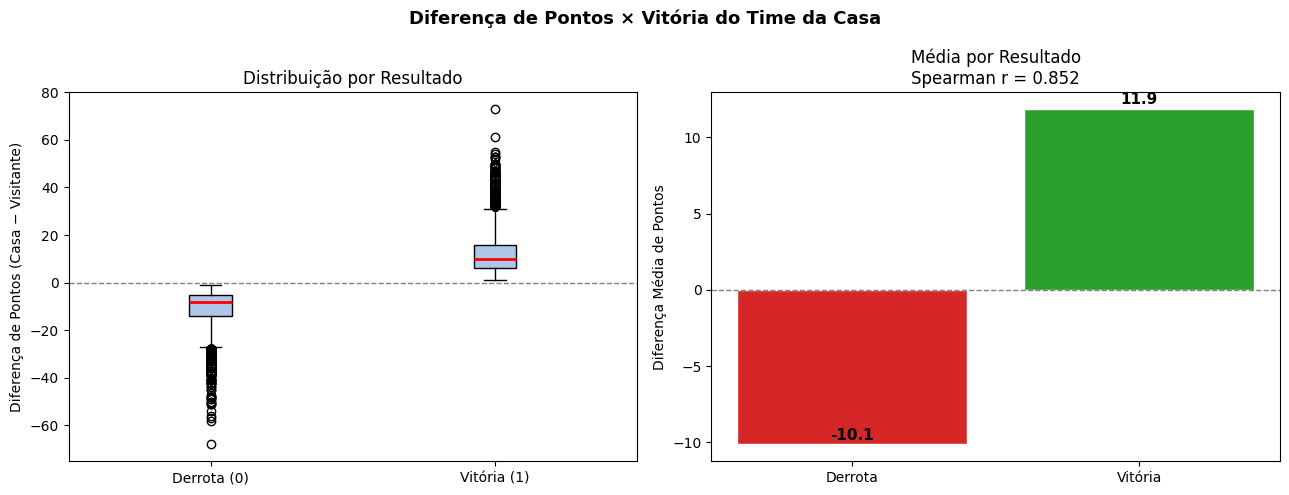

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Diferença de Pontos × Vitória do Time da Casa', fontsize=13, fontweight='bold')

# Boxplot
grupos = [df[df['HOME_TEAM_WINS'] == 0]['pts_diff'],
          df[df['HOME_TEAM_WINS'] == 1]['pts_diff']]
bp = axes[0].boxplot(grupos, labels=['Derrota (0)', 'Vitória (1)'],
                     patch_artist=True,
                     boxprops=dict(facecolor='#aec7e8'),
                     medianprops=dict(color='red', linewidth=2))
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylabel('Diferença de Pontos (Casa − Visitante)')
axes[0].set_title('Distribuição por Resultado')

# Médias por resultado
medias = df.groupby('HOME_TEAM_WINS')['pts_diff'].mean()
cores = ['#d62728', '#2ca02c']
bars = axes[1].bar(['Derrota', 'Vitória'], medias.values, color=cores, edgecolor='white')
for bar, val in zip(bars, medias.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('Diferença Média de Pontos')
axes[1].set_title(f'Média por Resultado\nSpearman r = {spearman_r2:.3f}')

plt.tight_layout()
plt.savefig('../visualizations/correlacao_diff_vitoria.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Análise 3 — Evolução da Correlação ao longo das Temporadas

A correlação entre PTS_home e PTS_away se mantém estável ao longo dos anos?

In [8]:
corr_por_temporada = df.groupby('SEASON').apply(
    lambda g: pd.Series({
        'pearson_r': stats.pearsonr(g['PTS_home'], g['PTS_away'])[0],
        'spearman_r': stats.spearmanr(g['PTS_home'], g['PTS_away'])[0],
        'n_jogos': len(g)
    })
).reset_index()

print(corr_por_temporada.to_string(index=False))

 SEASON  pearson_r  spearman_r  n_jogos
   2003   0.500817    0.471395   1286.0
   2004   0.460717    0.429270   1362.0
   2005   0.462485    0.424170   1432.0
   2006   0.469093    0.428462   1419.0
   2007   0.441199    0.408772   1411.0
   2008   0.438185    0.409625   1425.0
   2009   0.375074    0.349518   1424.0
   2010   0.429462    0.411645   1422.0
   2011   0.337281    0.306856   1104.0
   2012   0.353354    0.330802   1420.0
   2013   0.369855    0.344528   1427.0
   2014   0.340813    0.306970   1418.0
   2015   0.341153    0.320591   1416.0
   2016   0.342495    0.334282   1405.0
   2017   0.334762    0.328613   1382.0
   2018   0.343851    0.304649   1378.0
   2019   0.358847    0.331458   1241.0
   2020   0.266174    0.239252   1220.0
   2021   0.239342    0.233095   1389.0
   2022   0.307775    0.297283    542.0


/sessions/festive-stoic-einstein/tmp/ipykernel_301/3547434373.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_por_temporada = df.groupby('SEASON').apply(


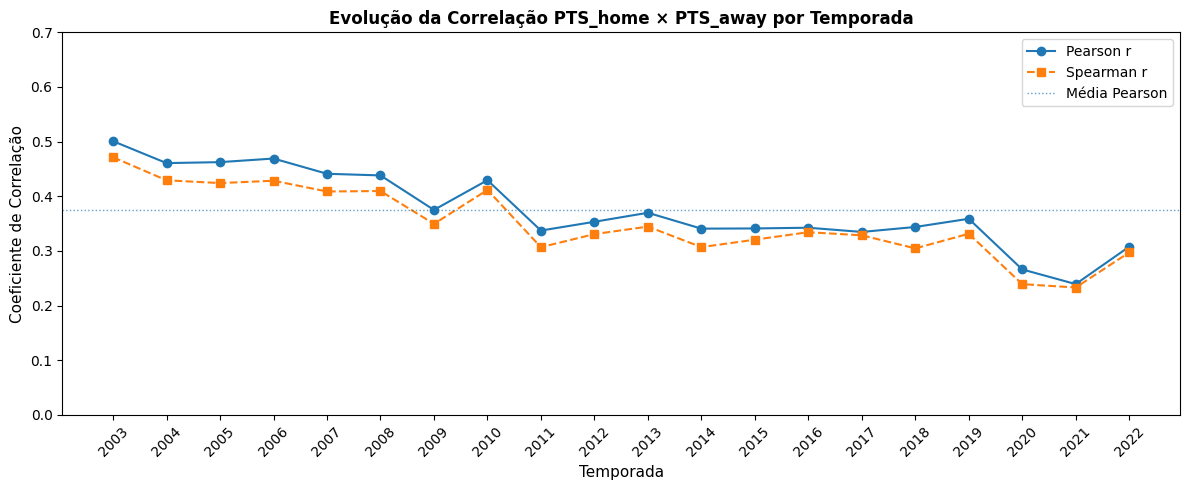


Insight: A correlação foi diminuindo ao longo das temporadas,
possivelmente pelo aumento do ritmo de jogo (mais pace) e maior variância nos estilos de jogo.


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(corr_por_temporada['SEASON'], corr_por_temporada['pearson_r'],
        marker='o', color='#1f77b4', label='Pearson r')
ax.plot(corr_por_temporada['SEASON'], corr_por_temporada['spearman_r'],
        marker='s', color='#ff7f0e', linestyle='--', label='Spearman r')

ax.axhline(corr_por_temporada['pearson_r'].mean(), color='#1f77b4',
           linestyle=':', linewidth=1, alpha=0.7, label='Média Pearson')

ax.set_xlabel('Temporada', fontsize=11)
ax.set_ylabel('Coeficiente de Correlação', fontsize=11)
ax.set_title('Evolução da Correlação PTS_home × PTS_away por Temporada', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(corr_por_temporada['SEASON'])
ax.set_xticklabels(corr_por_temporada['SEASON'], rotation=45)
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig('../visualizations/correlacao_por_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInsight: A correlação foi diminuindo ao longo das temporadas,')
print('possivelmente pelo aumento do ritmo de jogo (mais pace) e maior variância nos estilos de jogo.')

## 5. Matriz de Correlação — Heatmap

A matriz de correlação permite visualizar de forma consolidada as relações entre todas as variáveis numéricas do dataset. O mapa de calor facilita a identificação visual de correlações fortes (positivas em azul escuro, negativas em vermelho escuro) e fracas (tons claros próximos de zero).

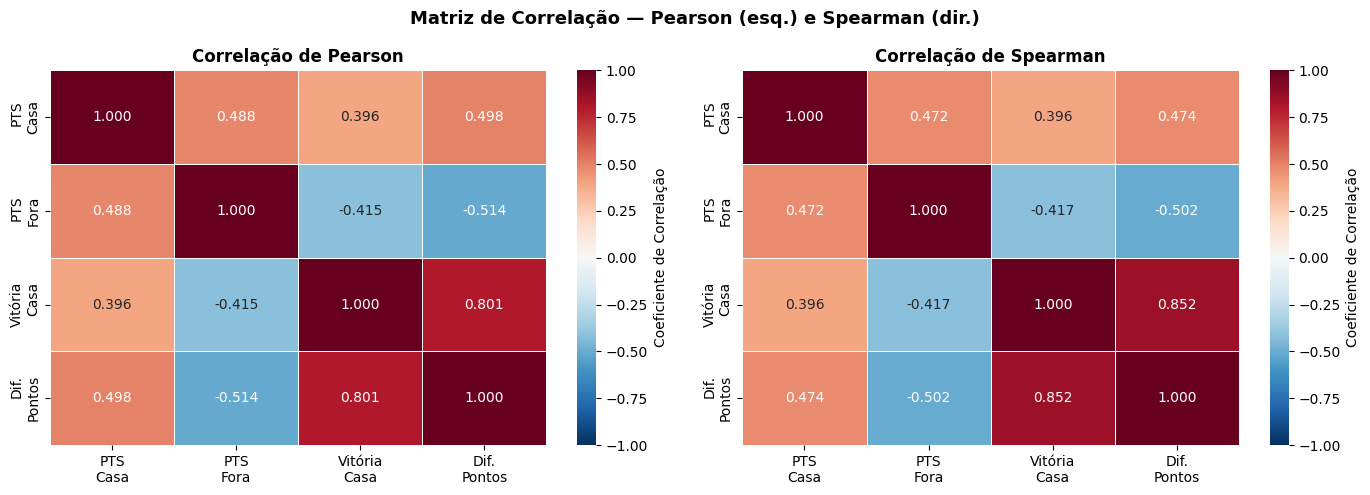

Heatmap salvo em: visualizations/heatmap_correlacao.png


In [10]:
import seaborn as sns

# Selecionar variáveis numéricas relevantes
vars_corr = ['PTS_home', 'PTS_away', 'HOME_TEAM_WINS', 'pts_diff']
df_corr = df[vars_corr].copy()

# Calcular matrizes de correlação
corr_pearson  = df_corr.corr(method='pearson').round(3)
corr_spearman = df_corr.corr(method='spearman').round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matriz de Correlação — Pearson (esq.) e Spearman (dir.)', fontsize=13, fontweight='bold')

labels = ['PTS\nCasa', 'PTS\nFora', 'Vitória\nCasa', 'Dif.\nPontos']

for ax, corr_mat, titulo in [
    (axes[0], corr_pearson,  'Pearson'),
    (axes[1], corr_spearman, 'Spearman'),
]:
    sns.heatmap(
        corr_mat, annot=True, fmt='.3f', cmap='RdBu_r',
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        xticklabels=labels, yticklabels=labels, ax=ax,
        cbar_kws={'label': 'Coeficiente de Correlação'}
    )
    ax.set_title(f'Correlação de {titulo}', fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/heatmap_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap salvo em: visualizations/heatmap_correlacao.png')

### Interpretação — Heatmap de Correlação

O heatmap revela de forma visual as relações entre as variáveis numéricas do dataset:

- A **correlação entre PTS_home e PTS_away** (~0.49 em Pearson) indica uma relação positiva moderada — quando a pontuação de um time sobe, a do adversário também tende a subir, possivelmente por características do jogo (ritmo, estilo de arbitragem).
- A **correlação entre pts_diff e HOME_TEAM_WINS** (~0.80 em Pearson) é forte e esperada — quanto maior a diferença de pontos a favor do mandante, maior a probabilidade de vitória.
- As correlações de **Pearson e Spearman** são muito similares, confirmando que os resultados são robustos e não dependem de suposições de normalidade.

## 6. Resumo Final

In [11]:
print('=' * 65)
print('       RESUMO DA ANÁLISE DE CORRELAÇÃO — NBA')
print('=' * 65)
print()
print('1. PTS_home × PTS_away')
print(f'   Pearson  r = {pearson_r:.4f}  (correlação positiva moderada)')
print(f'   Spearman r = {spearman_r:.4f}  (confirma linearidade)')
print('   → Escolha: Pearson (dados contínuos, distribuição quase normal)')
print()
print('2. Diferença de Pontos × HOME_TEAM_WINS')
print(f'   Pearson  r = {pearson_r2:.4f}  ')
print(f'   Spearman r = {spearman_r2:.4f}  (correlação muito forte)')
print('   → Escolha: Spearman (HOME_TEAM_WINS é variável binária/ordinal)')
print()
print('3. Tendência temporal')
print('   A correlação entre pontuações diminuiu de ~0.50 (2003)')
print('   para ~0.24 (2021), refletindo mudanças no estilo de jogo da NBA.')
print()
print('Conclusão: o fator casa se manifesta tanto na pontuação')
print('(times da casa pontuam em média +2.8 pts a mais) quanto')
print(f'na taxa de vitórias ({df["HOME_TEAM_WINS"].mean()*100:.1f}% de vitórias em casa).')
print('=' * 65)

       RESUMO DA ANÁLISE DE CORRELAÇÃO — NBA

1. PTS_home × PTS_away
   Pearson  r = 0.4881  (correlação positiva moderada)
   Spearman r = 0.4723  (confirma linearidade)
   → Escolha: Pearson (dados contínuos, distribuição quase normal)

2. Diferença de Pontos × HOME_TEAM_WINS
   Pearson  r = 0.8010  
   Spearman r = 0.8524  (correlação muito forte)
   → Escolha: Spearman (HOME_TEAM_WINS é variável binária/ordinal)

3. Tendência temporal
   A correlação entre pontuações diminuiu de ~0.50 (2003)
   para ~0.24 (2021), refletindo mudanças no estilo de jogo da NBA.

Conclusão: o fator casa se manifesta tanto na pontuação
(times da casa pontuam em média +2.8 pts a mais) quanto
na taxa de vitórias (58.9% de vitórias em casa).
